Libraries imported successfully!
Input file: ../../task1_air_quality\outputs\air_quality_cleaned.csv
Output directory: ../../task4_supervised_learning\outputs

Dataset loaded successfully!
Shape: (9357, 13)

First 5 rows:


,Datetime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888



Column names:
['Datetime', 'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Data types:
Datetime             str
CO(GT)           float64
PT08.S1(CO)      float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

Missing values:
Datetime         0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

Duplicate rows: 0

Numerical columns:
['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'Day', 'Month',

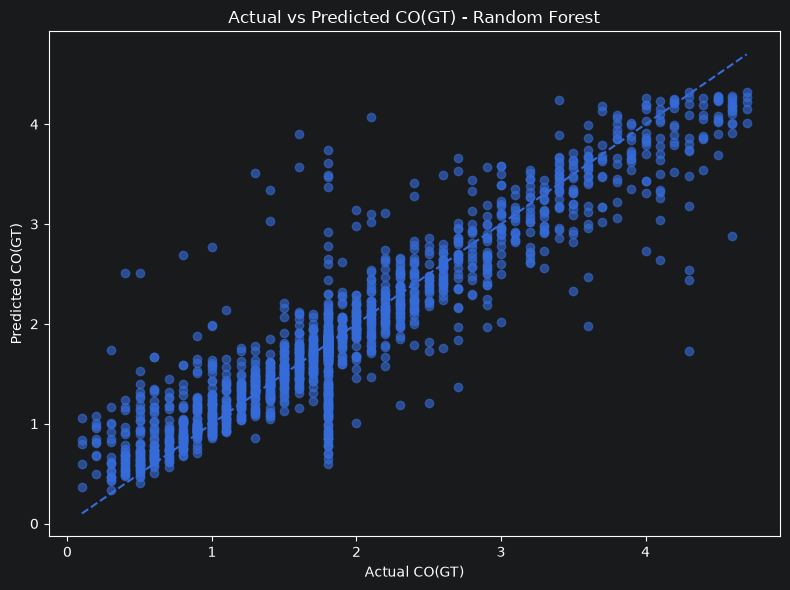

Saved: ../../task4_supervised_learning\outputs\figures\actual_vs_predicted.png

Random Forest Feature Importance:
      Feature  Importance
PT08.S2(NMHC)      0.5670
      NOx(GT)      0.1873
     C6H6(GT)      0.0669
      NO2(GT)      0.0250
         Hour      0.0239
  PT08.S1(CO)      0.0219
            T      0.0185
          Day      0.0135
 PT08.S4(NO2)      0.0134
        Month      0.0120
  PT08.S5(O3)      0.0117
 PT08.S3(NOx)      0.0115
           RH      0.0114
           AH      0.0094
    DayOfWeek      0.0067

Feature importance saved:
../../task4_supervised_learning\outputs\feature_importance.csv


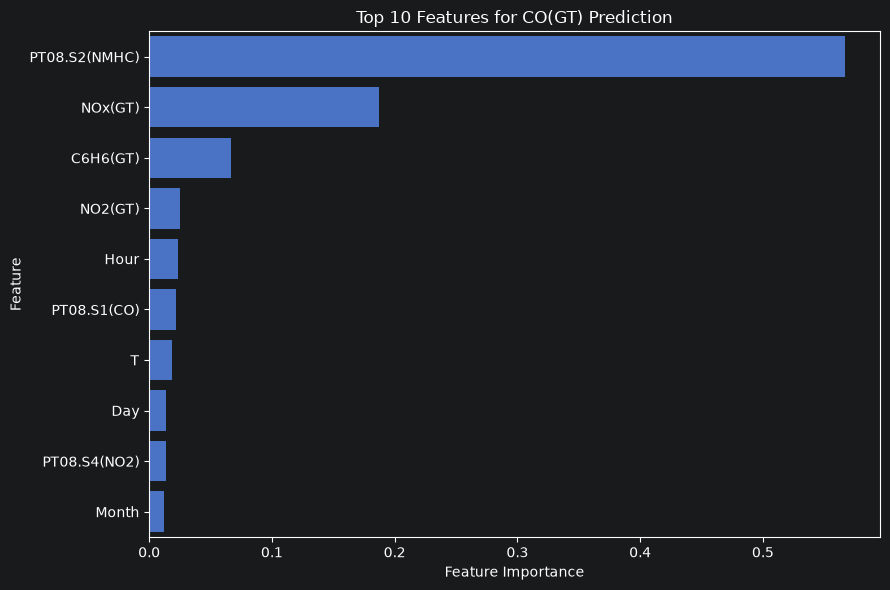

Saved: ../../task4_supervised_learning\outputs\figures\feature_importance.png


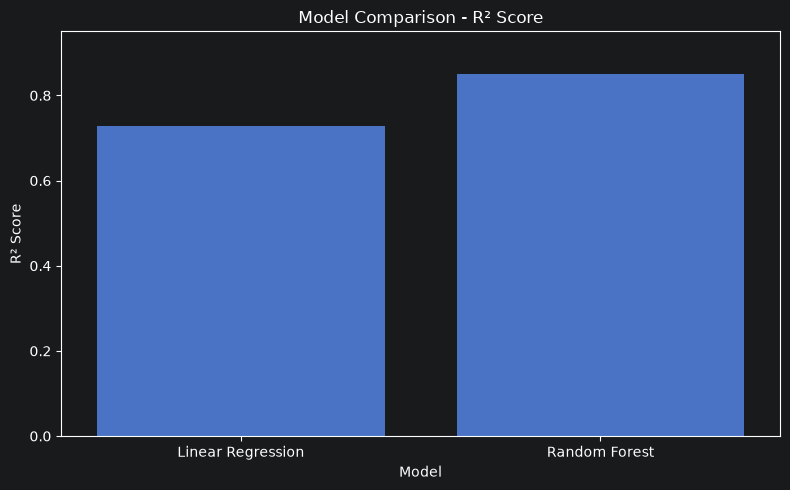

Saved: ../../task4_supervised_learning\outputs\figures\model_performance.png


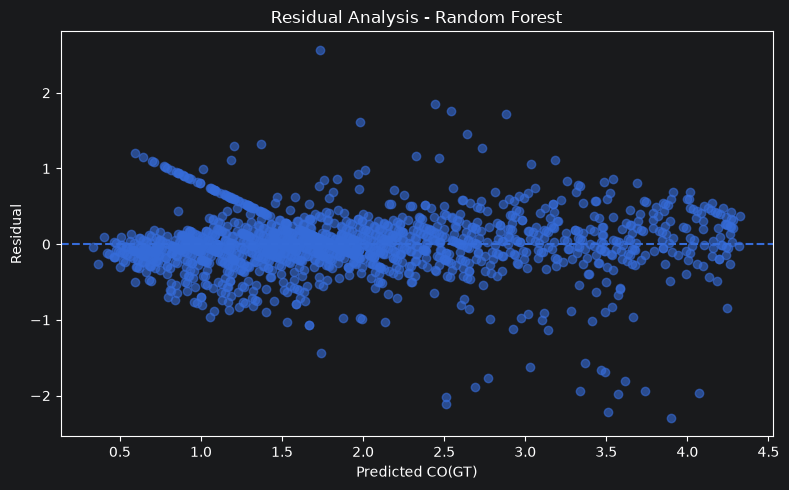

Saved: ../../task4_supervised_learning\outputs\figures\residual_analysis.png

Predictions saved:
../../task4_supervised_learning\outputs\predictions.csv

TASK 4 - FINAL SUMMARY

Dataset shape used: (8903, 16)

Target variable: CO(GT)

Number of features: 15

Training samples: 7122
Testing samples: 1781

Model Performance:
            Model    MAE    MSE   RMSE  R2 Score
Linear Regression 0.3571 0.2612 0.5111    0.7282
    Random Forest 0.2366 0.1436 0.3789    0.8506

Best Model: Random Forest
Best R²: 0.8506
Best RMSE: 0.3789
Best MAE: 0.2366

Top 5 Important Features:
      Feature  Importance
PT08.S2(NMHC)      0.5670
      NOx(GT)      0.1873
     C6H6(GT)      0.0669
      NO2(GT)      0.0250
         Hour      0.0239

Output files saved in:
C:\Users\harsh\YuvaIntern_Data_Science_Project\task4_supervised_learning\outputs

Task 4 completed successfully!


In [1]:
# ============================================================
# TASK 4: SUPERVISED LEARNING MODEL IMPLEMENTATION
# Air Quality Dataset - CO(GT) Prediction
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


# ============================================================
# 2. DEFINE PATHS
# ============================================================

# Project structure:
#
# YuvaIntern_Data_Science_Project/
# ├── task1_air_quality/
# │   └── outputs/
# │       └── air_quality_cleaned.csv
# │
# └── task4_supervised_learning/
#     └── notebooks/
#         └── task4_supervised_learning.ipynb

BASE_DIR = "../../"

INPUT_PATH = os.path.join(
    BASE_DIR,
    "task1_air_quality",
    "outputs",
    "air_quality_cleaned.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "task4_supervised_learning",
    "outputs"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Input file:", INPUT_PATH)
print("Output directory:", OUTPUT_DIR)


# ============================================================
# 3. LOAD CLEANED DATASET
# ============================================================

if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(
        f"Dataset not found:\n{INPUT_PATH}\n\n"
        "Make sure Task 1 cleaned dataset exists."
    )

df = pd.read_csv(INPUT_PATH)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())


# ============================================================
# 4. BASIC DATA INSPECTION
# ============================================================

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


# ============================================================
# 5. CONVERT DATETIME IF PRESENT
# ============================================================

if "Datetime" in df.columns:
    df["Datetime"] = pd.to_datetime(
        df["Datetime"],
        errors="coerce"
    )

    # Extract useful time-based features
    df["Hour"] = df["Datetime"].dt.hour
    df["Day"] = df["Datetime"].dt.day
    df["Month"] = df["Datetime"].dt.month
    df["DayOfWeek"] = df["Datetime"].dt.dayofweek

    # Remove original datetime because ML models
    # cannot directly use datetime objects.
    df = df.drop(columns=["Datetime"])

elif "DateTime" in df.columns:
    df["DateTime"] = pd.to_datetime(
        df["DateTime"],
        errors="coerce"
    )

    df["Hour"] = df["DateTime"].dt.hour
    df["Day"] = df["DateTime"].dt.day
    df["Month"] = df["DateTime"].dt.month
    df["DayOfWeek"] = df["DateTime"].dt.dayofweek

    df = df.drop(columns=["DateTime"])


# ============================================================
# 6. REMOVE NON-NUMERICAL COLUMNS
# ============================================================

# CO(GT) is our target variable.
TARGET = "CO(GT)"

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found.\n"
        f"Available columns:\n{df.columns.tolist()}"
    )

# Keep numerical columns only
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumerical columns:")
print(numeric_columns)


# ============================================================
# 7. HANDLE MISSING VALUES
# ============================================================

# Replace infinite values
df = df.replace([np.inf, -np.inf], np.nan)

# Fill numerical missing values with median
for column in df.select_dtypes(include=np.number).columns:
    df[column] = df[column].fillna(df[column].median())

print("\nMissing values after handling:")
print(df.isna().sum().sum())


# ============================================================
# 8. REMOVE TARGET OUTLIERS USING IQR
# ============================================================

# We do not aggressively remove all feature outliers because
# environmental extremes can represent genuine observations.

Q1 = df[TARGET].quantile(0.25)
Q3 = df[TARGET].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before_rows = len(df)

df_model = df[
    (df[TARGET] >= lower_bound) &
    (df[TARGET] <= upper_bound)
].copy()

after_rows = len(df_model)

print("\nTarget outlier handling:")
print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Rows removed:", before_rows - after_rows)


# ============================================================
# 9. CREATE FEATURES AND TARGET
# ============================================================

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Keep only numerical predictors
X = X.select_dtypes(include=np.number)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used:")
print(X.columns.tolist())


# ============================================================
# 10. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
# 11. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


# ============================================================
# 12. LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_predictions = linear_model.predict(
    X_test_scaled
)

print("\nLinear Regression trained successfully!")


# ============================================================
# 13. RANDOM FOREST REGRESSION
# ============================================================

random_forest = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(
    X_test
)

print("Random Forest trained successfully!")


# ============================================================
# 14. EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }


# ============================================================
# 15. EVALUATE BOTH MODELS
# ============================================================

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)

results_df = pd.DataFrame(results)

print("\n================ MODEL PERFORMANCE ================\n")

print(
    results_df.round(4).to_string(index=False)
)


# ============================================================
# 16. SAVE MODEL COMPARISON
# ============================================================

results_path = os.path.join(
    OUTPUT_DIR,
    "model_comparison.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("\nModel comparison saved:")
print(results_path)


# ============================================================
# 17. SELECT BEST MODEL
# ============================================================

best_model_row = results_df.loc[
    results_df["R2 Score"].idxmax()
]

best_model_name = best_model_row["Model"]

print("\nBest model based on R²:")
print(best_model_name)


# ============================================================
# 18. ACTUAL VS PREDICTED - BEST MODEL
# ============================================================

if best_model_name == "Random Forest":
    best_predictions = rf_predictions
else:
    best_predictions = linear_predictions


plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title(
    f"Actual vs Predicted CO(GT) - {best_model_name}"
)

plt.tight_layout()

actual_predicted_path = os.path.join(
    FIGURE_DIR,
    "actual_vs_predicted.png"
)

plt.savefig(
    actual_predicted_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", actual_predicted_path)


# ============================================================
# 19. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nRandom Forest Feature Importance:")
print(
    feature_importance.round(4).to_string(index=False)
)


# ============================================================
# 20. SAVE FEATURE IMPORTANCE
# ============================================================

importance_path = os.path.join(
    OUTPUT_DIR,
    "feature_importance.csv"
)

feature_importance.to_csv(
    importance_path,
    index=False
)

print("\nFeature importance saved:")
print(importance_path)


# ============================================================
# 21. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

top_features = feature_importance.head(10)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Features for CO(GT) Prediction"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

importance_figure_path = os.path.join(
    FIGURE_DIR,
    "feature_importance.png"
)

plt.savefig(
    importance_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", importance_figure_path)


# ============================================================
# 22. MODEL PERFORMANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.ylim(
    min(0, results_df["R2 Score"].min() - 0.1),
    min(1, results_df["R2 Score"].max() + 0.1)
)

plt.tight_layout()

performance_path = os.path.join(
    FIGURE_DIR,
    "model_performance.png"
)

plt.savefig(
    performance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", performance_path)


# ============================================================
# 23. RESIDUAL ANALYSIS
# ============================================================

residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted CO(GT)")
plt.ylabel("Residual")
plt.title(
    f"Residual Analysis - {best_model_name}"
)

plt.tight_layout()

residual_path = os.path.join(
    FIGURE_DIR,
    "residual_analysis.png"
)

plt.savefig(
    residual_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", residual_path)


# ============================================================
# 24. SAVE PREDICTIONS
# ============================================================

predictions_df = pd.DataFrame({
    "Actual_CO_GT": y_test.values,
    "Predicted_CO_GT": best_predictions,
    "Residual": residuals.values
})

predictions_path = os.path.join(
    OUTPUT_DIR,
    "predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

print("\nPredictions saved:")
print(predictions_path)


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("TASK 4 - FINAL SUMMARY")
print("=" * 60)

print("\nDataset shape used:", df_model.shape)

print("\nTarget variable:", TARGET)

print("\nNumber of features:", X.shape[1])

print("\nTraining samples:", len(X_train))

print("Testing samples:", len(X_test))

print("\nModel Performance:")
print(results_df.round(4).to_string(index=False))

print("\nBest Model:", best_model_name)

print(
    "Best R²:",
    round(best_model_row["R2 Score"], 4)
)

print(
    "Best RMSE:",
    round(best_model_row["RMSE"], 4)
)

print(
    "Best MAE:",
    round(best_model_row["MAE"], 4)
)

print("\nTop 5 Important Features:")

print(
    feature_importance.head(5).round(4).to_string(index=False)
)

print("\nOutput files saved in:")
print(os.path.abspath(OUTPUT_DIR))

